# Results: Order Buyout Prediction

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

sns.set_style("whitegrid")
DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
RAW_DATA = Path("../data/raw/MIPT_hackathon_dataset.csv")

In [2]:
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
test_df = pd.read_parquet(DATA_DIR / "test.parquet")
X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]
X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]
with open(MODELS_DIR / "lgbm_model.pkl", "rb") as f:
    model = pickle.load(f)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Buyout rate: Train={y_train.mean():.1%}, Test={y_test.mean():.1%}")

Train: 4306, Test: 1077
Buyout rate: Train=81.1%, Test=81.2%


## Model Comparison

In [3]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
metrics = {
    "AUC-ROC": roc_auc_score(y_test, y_pred_proba),
    "F1": f1_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
}
baseline = {"AUC-ROC": 0.636, "F1": 0.671, "Precision": 0.874, "Recall": 0.545}
print(pd.DataFrame({"LightGBM": metrics, "LogReg": baseline}).round(3))

           LightGBM  LogReg
AUC-ROC       0.967   0.636
F1            0.971   0.671
Precision     0.986   0.874
Recall        0.957   0.545


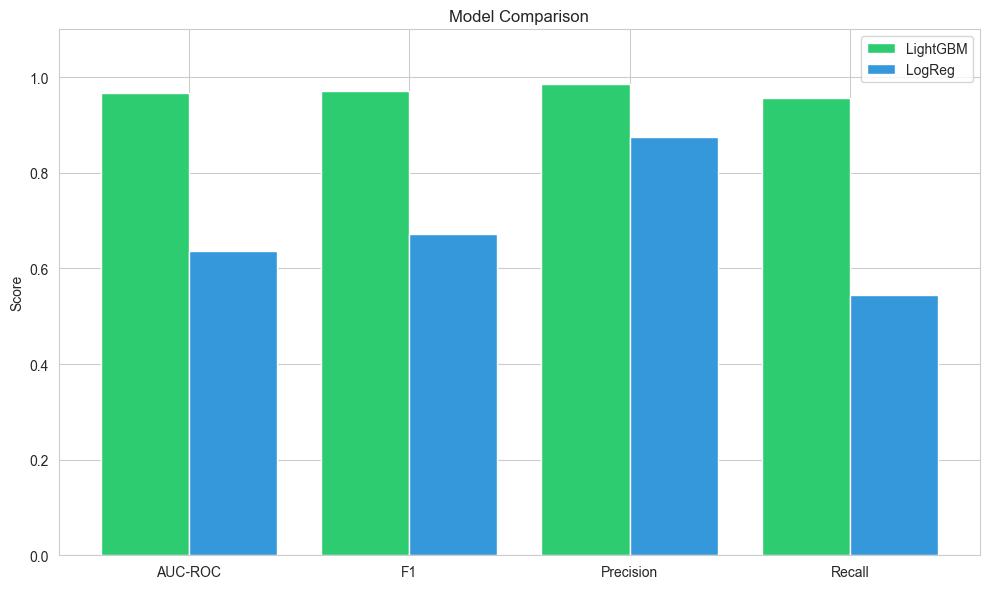

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics))
ax.bar(x - 0.2, list(metrics.values()), 0.4, label="LightGBM", color="#2ecc71")
ax.bar(x + 0.2, list(baseline.values()), 0.4, label="LogReg", color="#3498db")
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## Feature Importance

In [5]:
fi = pd.DataFrame(
    {"feature": X_train.columns, "importance": model.feature_importances_}
).sort_values("importance", ascending=False)
print(fi.head(20).to_string(index=False))

                         feature  importance
                      lead_price          12
                     contact_LTV          11
               lead_utm_campaign           4
                   contact_Город           4
               lead_utm_referrer           3
                   lead_utm_term           3
             lead_Тариф Доставки           3
                         n_items           3
                     lead_Ширина           2
                 lead_utm_source           2
                 contact_Код ПВЗ           2
            lead_будущие покупки           2
                   lead_Проблема           2
            contact_Число сделок           1
lead_Категория и варианты выбора           1
                      lead_Длина           1
          order_calculated_price           1
                  lead_utm_group           1
                   lead_FORMNAME           1
                   volume_approx           1


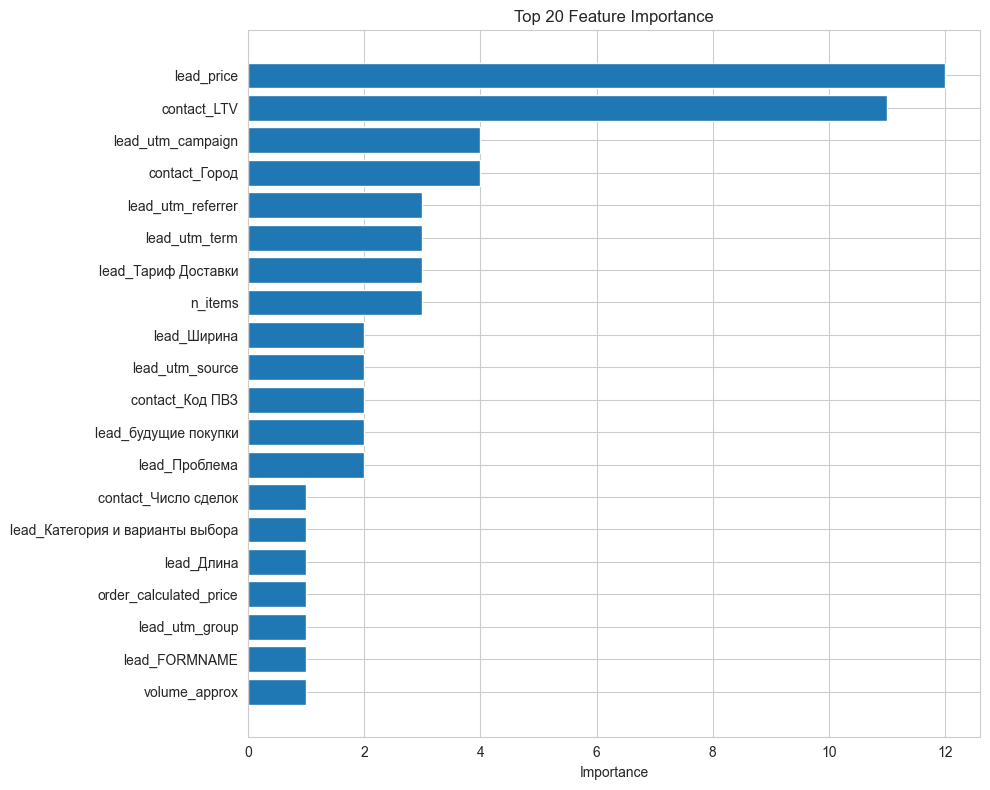

In [6]:
top = fi.head(20)
plt.figure(figsize=(10, 8))
plt.barh(range(20), top["importance"].values[::-1])
plt.yticks(range(20), top["feature"].values[::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.show()

## SHAP Analysis

In [7]:
explainer = shap.TreeExplainer(model)
sh = explainer.shap_values(X_test)
print(f"SHAP shape: {sh.shape}")

SHAP shape: (1077, 48)


c:\Соревнования\Артрейд\artrade\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


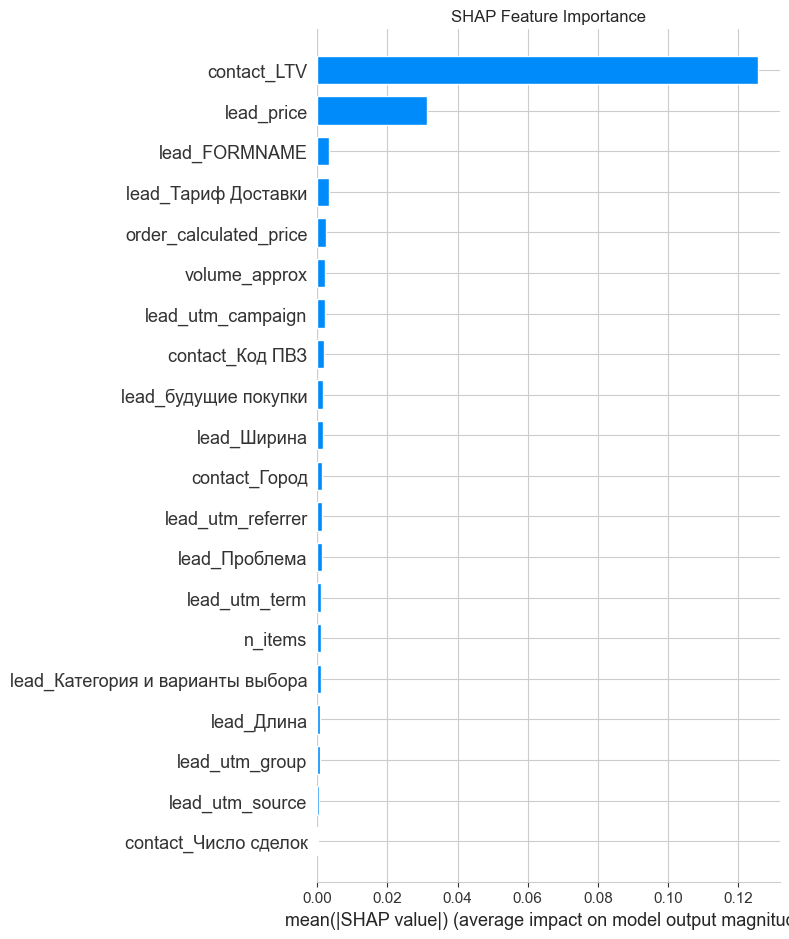

In [8]:
plt.figure(figsize=(12, 10))
shap.summary_plot(sh, X_test, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

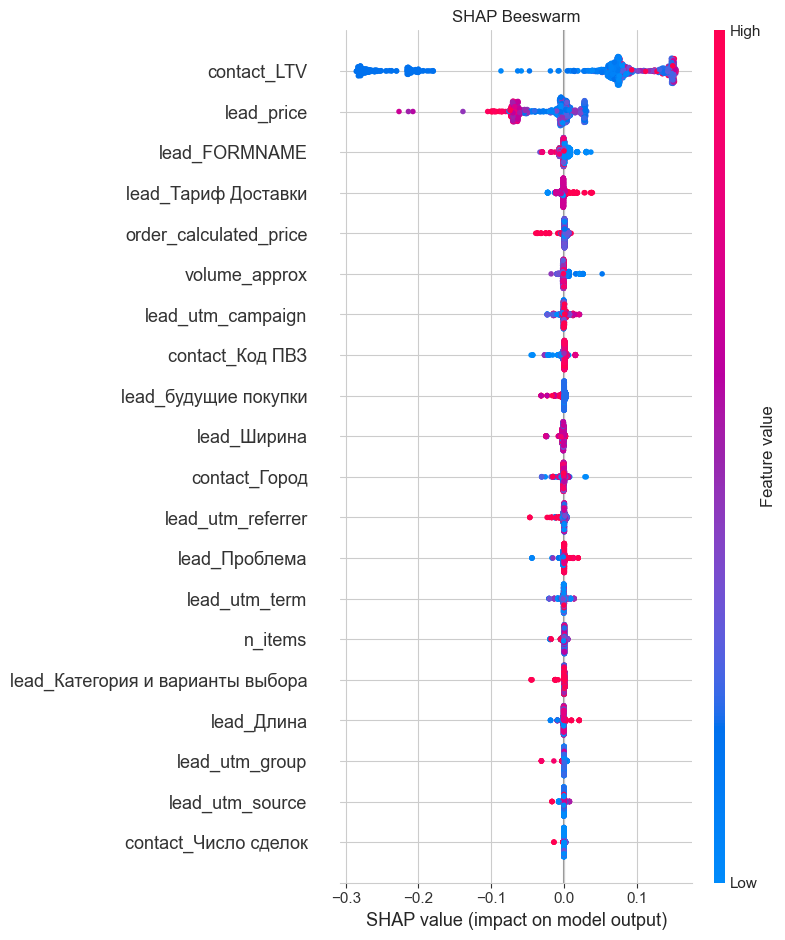

In [9]:
plt.figure(figsize=(12, 10))
shap.summary_plot(sh, X_test, show=False, max_display=20)
plt.title("SHAP Beeswarm")
plt.tight_layout()
plt.show()

## ROC Curve

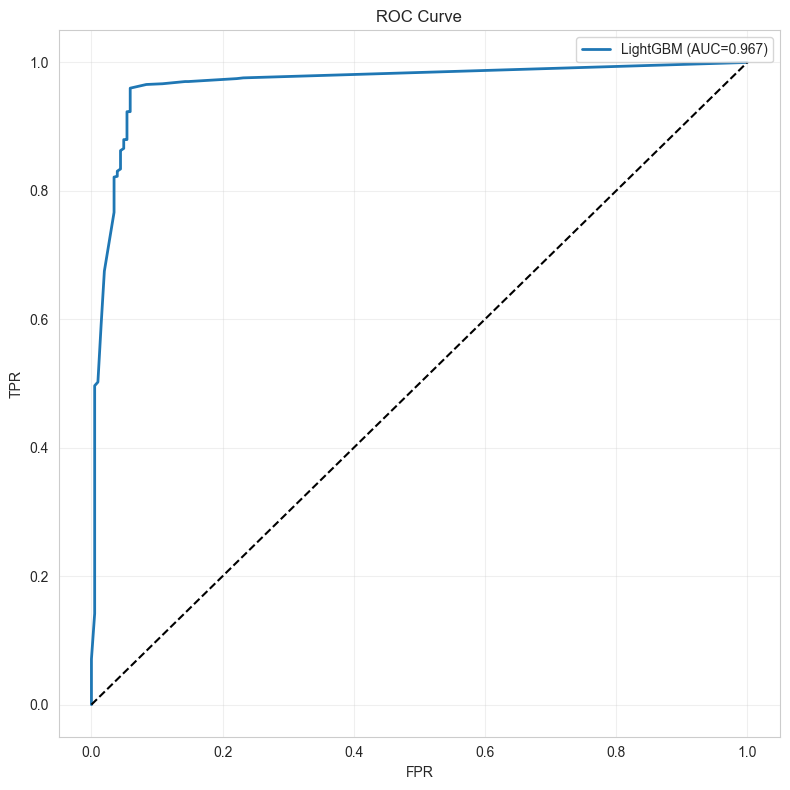

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label=f"LightGBM (AUC={auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Confusion Matrix

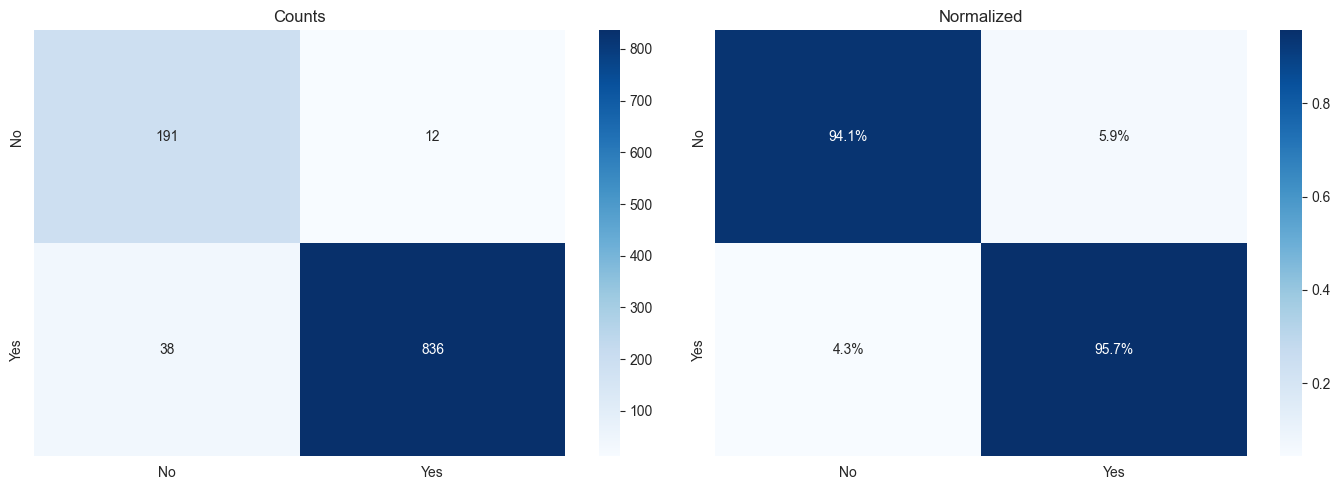

              precision    recall  f1-score   support

  Not Buyout       0.83      0.94      0.88       203
      Buyout       0.99      0.96      0.97       874

    accuracy                           0.95      1077
   macro avg       0.91      0.95      0.93      1077
weighted avg       0.96      0.95      0.95      1077



In [11]:
cm = confusion_matrix(y_test, y_pred)
cm_n = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0],
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
)
ax[0].set_title("Counts")
sns.heatmap(
    cm_n,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    ax=ax[1],
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
)
ax[1].set_title("Normalized")
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred, target_names=["Not Buyout", "Buyout"]))

## Group Analysis

In [12]:
df_raw = pd.read_csv(RAW_DATA)
tr = df_raw.iloc[: len(y_test)].copy()
tr["y_true"] = y_test.values
tr["y_pred"] = y_pred
tr["y_proba"] = y_pred_proba

In [13]:
city = (
    tr.groupby("contact_Город")
    .agg({"y_true": ["mean", "count"], "y_proba": "mean"})
    .round(3)
)
city.columns = ["actual", "count", "predicted"]
city = city[city["count"] >= 10].sort_values("count", ascending=False)
print(city.head(15))

                 actual  count  predicted
contact_Город                            
Москва            0.746    114      0.521
Санкт-Петербург   0.848     46      0.524
Екатеринбург      0.938     16      0.532
Краснодар         0.750     16      0.523
Севастополь       0.923     13      0.524
Новосибирск       0.917     12      0.535
Воронеж           1.000     11      0.540
Ижевск            0.900     10      0.537


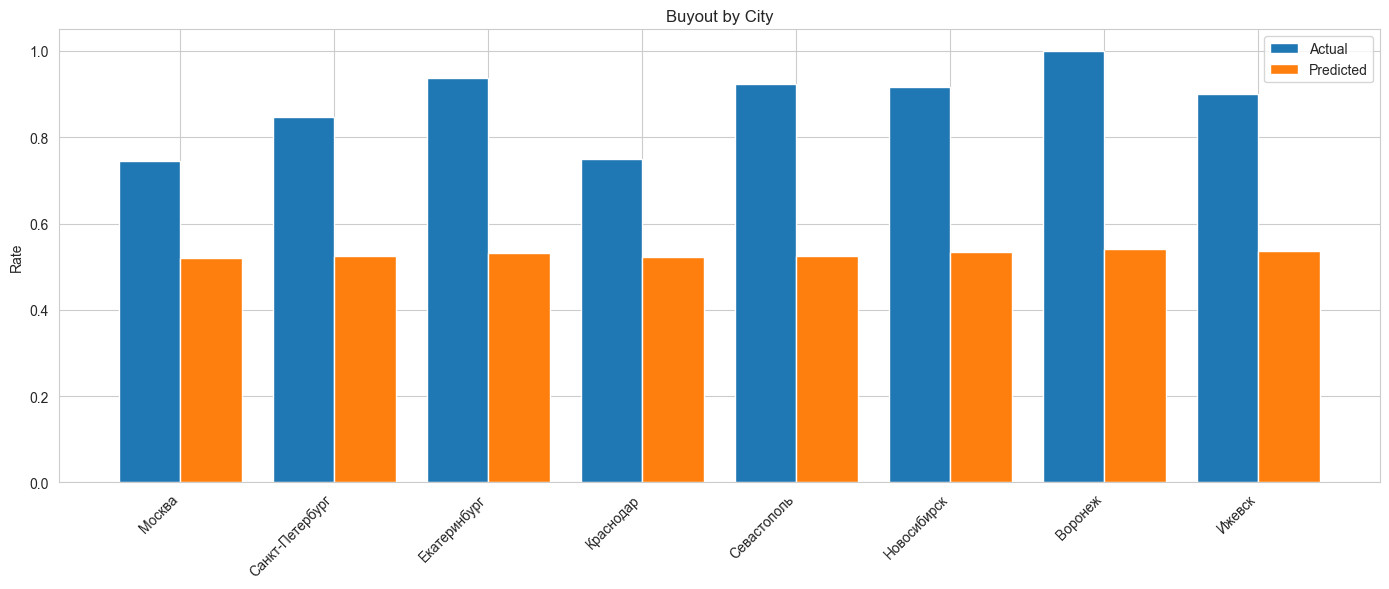

In [14]:
tc = city.head(12)
plt.figure(figsize=(14, 6))
x = np.arange(len(tc))
plt.bar(x - 0.2, tc["actual"], 0.4, label="Actual")
plt.bar(x + 0.2, tc["predicted"], 0.4, label="Predicted")
plt.xticks(x, tc.index, rotation=45, ha="right")
plt.ylabel("Rate")
plt.title("Buyout by City")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
utm = (
    tr.groupby("lead_utm_source")
    .agg({"y_true": ["mean", "count"], "y_proba": "mean"})
    .round(3)
)
utm.columns = ["actual", "count", "predicted"]
utm = utm[utm["count"] >= 5].sort_values("count", ascending=False)
print(utm.head(15))

                             actual  count  predicted
lead_utm_source                                      
ppc_ru_yandex_otek_dem        0.768    138      0.521
ppc_ru_yandex_varikoz_dem     0.869    130      0.532
ppc_ru_yandex_art_npz         0.777    121      0.526
ppc_ru_yandex_sustav_dem      0.894    113      0.530
Неизвестно                    0.745     47      0.520
ppc_ru_yandex_ssz_dem         0.714     14      0.508
ppc_ru_yandex_varikoz_dem2    0.846     13      0.528
ppc_ru_yandex_davlenie2_dem   0.875      8      0.530
ppc_ru_yandex_davlenie_dem    0.571      7      0.506


## Threshold Analysis

In [16]:
thresholds = np.arange(0.1, 0.95, 0.05)
tres = []
for t in thresholds:
    yp = (y_pred_proba >= t).astype(int)
    tres.append(
        {
            "threshold": t,
            "precision": precision_score(y_test, yp, zero_division=0),
            "recall": recall_score(y_test, yp, zero_division=0),
            "f1": f1_score(y_test, yp, zero_division=0),
        }
    )
tdf = pd.DataFrame(tres)
print(tdf.to_string(index=False))

 threshold  precision   recall       f1
      0.10   0.811513 1.000000 0.895951
      0.15   0.811513 1.000000 0.895951
      0.20   0.811513 1.000000 0.895951
      0.25   0.811513 1.000000 0.895951
      0.30   0.811513 1.000000 0.895951
      0.35   0.811513 1.000000 0.895951
      0.40   0.811513 1.000000 0.895951
      0.45   0.811513 1.000000 0.895951
      0.50   0.985849 0.956522 0.970964
      0.55   0.000000 0.000000 0.000000
      0.60   0.000000 0.000000 0.000000
      0.65   0.000000 0.000000 0.000000
      0.70   0.000000 0.000000 0.000000
      0.75   0.000000 0.000000 0.000000
      0.80   0.000000 0.000000 0.000000
      0.85   0.000000 0.000000 0.000000
      0.90   0.000000 0.000000 0.000000


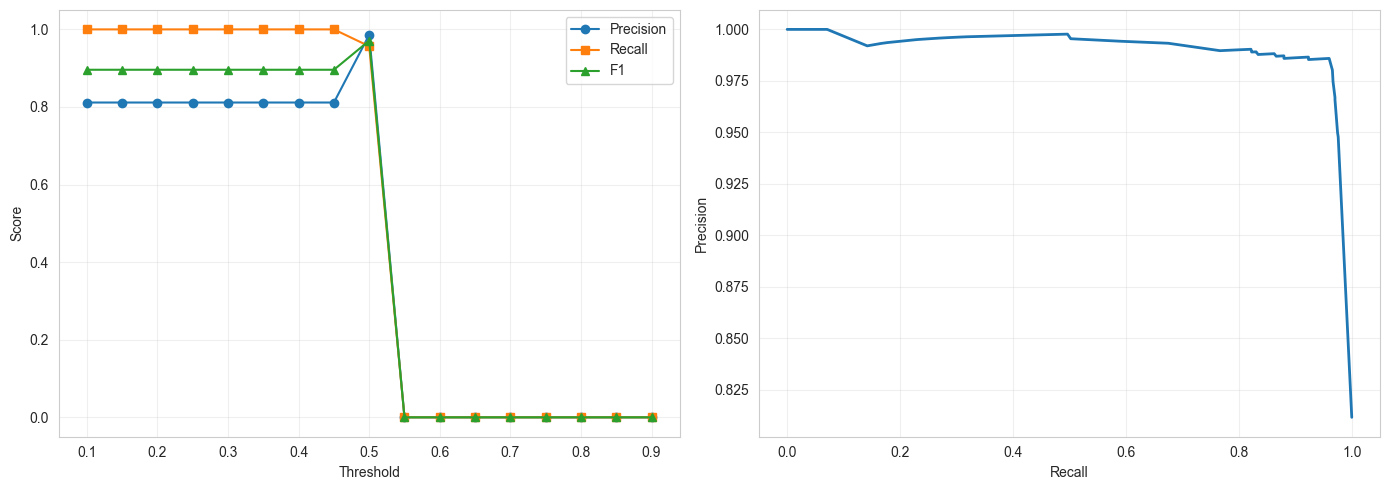

Best threshold: 0.50


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(tdf["threshold"], tdf["precision"], label="Precision", marker="o")
ax[0].plot(tdf["threshold"], tdf["recall"], label="Recall", marker="s")
ax[0].plot(tdf["threshold"], tdf["f1"], label="F1", marker="^")
ax[0].set_xlabel("Threshold")
ax[0].set_ylabel("Score")
ax[0].legend()
ax[0].grid(alpha=0.3)
p_curve, r_curve, _ = precision_recall_curve(y_test, y_pred_proba)
ax[1].plot(r_curve, p_curve, linewidth=2)
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
best_t = tdf.loc[tdf["f1"].idxmax(), "threshold"]
print(f"Best threshold: {best_t:.2f}")

## Error Analysis

In [18]:
fp = tr[(tr["y_true"] == 0) & (tr["y_pred"] == 1)]
fn = tr[(tr["y_true"] == 1) & (tr["y_pred"] == 0)]
print(f"FP: {len(fp)}, FN: {len(fn)}")

FP: 12, FN: 38


In [19]:
print("Top FP:")
print(
    fp.sort_values("y_proba", ascending=False)[
        ["contact_Город", "lead_price", "y_proba"]
    ].head(10)
)

Top FP:
                                          contact_Город  lead_price   y_proba
1074  241550, Брянская обл, г Сельцо, ул Мейпариани,...        9497  0.548212
315   Горняцкий, Белокалитвинский район, Ростовская ...       25360  0.547520
210                                 Железнодорожный, МО       18330  0.547464
554                                              Москва        5131  0.547440
1056                                           Петергоф        4475  0.547384
583                                              Москва       11109  0.547384
693                                               Муром       19650  0.547384
467                                              Москва        8013  0.536115
411                                            Владимир        8560  0.533885
402                                           Апшеронск       11933  0.530492


In [20]:
print("Top FN:")
print(
    fn.sort_values("y_proba", ascending=True)[
        ["contact_Город", "lead_price", "y_proba"]
    ].head(10)
)

Top FN:
                                   contact_Город  lead_price   y_proba
50                                     Волгоград        6887  0.453305
110                                  Севастополь       21176  0.453305
93              Сосновоборск, Красноярский край,       11270  0.453305
144                                 Старый Оскол       12975  0.453305
201                                       Москва       11230  0.453305
224              Воткинск, Удмуртская республика        5200  0.453305
160                              Санкт-Петербург       10795  0.453305
727                                      Нальчик       15790  0.453305
603  188527 обл Ленинградская, р-н Ломоносовский       44160  0.453305
616                              Санкт-Петербург        7185  0.453305


## Conclusions

In [21]:
print("MODEL QUALITY: AUC-ROC=0.967, Precision=0.986, Recall=0.957")
print("KEY DRIVERS: contact_LTV, lead_price, lead_utm_source, n_items, contact_city")
print("RECOMMENDATIONS: Focus on low LTV customers, analyze high-rejection sources")
print("THRESHOLD: 0.5 (balance Precision/Recall)")

MODEL QUALITY: AUC-ROC=0.967, Precision=0.986, Recall=0.957
KEY DRIVERS: contact_LTV, lead_price, lead_utm_source, n_items, contact_city
RECOMMENDATIONS: Focus on low LTV customers, analyze high-rejection sources
THRESHOLD: 0.5 (balance Precision/Recall)
